In [22]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from bspline_model import *
from workout import *





workout_df = pd.DataFrame([
    ('polar_data/oo_dd_2025-12-24_18-32-17.CSV', standard_3x4.name, 130, 0),
    ('polar_data/oo_dd_2025-12-30_11-32-46.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-02_17-45-25.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-05_16-54-37.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-07_17-13-36.CSV', standard_3x4.name, 240, 0), 
    ('polar_data/oo_dd_2026-01-15_16-59-15.CSV', xtrainer_4x4.name, 0, 0),
    ('polar_data/oo_dd_2026-01-18_16-31-02.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-01-29_17-17-32.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-02-03_17-40-57.CSV', standard_3x4.name, 240, 0),
    ('polar_data/oo_dd_2026-02-11_17-17-27.CSV', standard_3x4.name, 240, 0),
    ],
    columns=["file_path", "workout_config", "n_drop", "kernel_size"]).assign(
        session_name=lambda x: [Path(p).stem[6:16] for p in x.file_path],
        cache_path=lambda x: [Path(p).with_suffix(".nc") for p in x.file_path]
    )

knots_data = {
    "2025-12-24": np.array(list(sorted(
        set(range(0, 841, 40)) | {152, 162, 200, 210, 240, 256, 388, 660, 720}
        ))).reshape((-1, 1)),
    "2025-12-30": np.array(list(sorted(
        set(range(0, 854, 30)) | {126, 145, 700, 734, 747}
    ))).reshape((-1, 1)),
    "2026-01-02": np.array(list(sorted(
        set(range(0, 847, 40)) | {222, 242, 420, 440, 485, 527, 698, 726}
    ))).reshape((-1, 1)),
    "2026-01-05": np.array(list(sorted(
        set(range(0, 848, 40)) | {210, 225, 260, 419, 454, 505, 560, 616, 700, 731}
    ))).reshape((-1, 1)),
    "2026-01-07": np.array(list(sorted(
        set(range(0, 848, 40)) | {210, 225, 260, 419, 454, 505, 560, 700, 731}
    ))).reshape((-1, 1)),
    "2026-01-18": np.array(list(sorted(
        set(range(0, 866, 40)) | {210, 225, 250, 260, 470, 455, 490, 505, 560, 700, 727, 740}
    ))).reshape((-1, 1)),
    "2026-01-29": np.array(list(sorted(
        set(range(0, 850, 40)) | {60, 450, 547, 700, 786}
    ))).reshape((-1, 1)),
    "2026-02-03": np.array(list(sorted(
        (set(range(0, 850, 40)) - {640}) | {290}
    ))).reshape((-1, 1)),
    "2026-02-11": np.array(list(sorted(
        (set(range(0, 850, 40))) | {223, 295, 456, 671, 743, 494, 729}
    ))).reshape((-1, 1)),
}

wc = standard_3x4
load_cache = True
sessions = []
for i, session_row in list(workout_df.loc[lambda x: x.workout_config == wc.name].iterrows()):
    
    # if session_row.session_name != "2026-02-11":
    #     continue
    
    session_df = pd.read_csv(session_row.file_path, skiprows=2).iloc[session_row.n_drop:, 1:3].assign(
        time_sec=lambda x: pd.to_timedelta(x.Time).dt.total_seconds() - session_row.n_drop
    )
    # print(session_row.session_name)
    # print(session_df.time_sec.shape[0])
    bsm = BsplineModel(knots=knots_data[session_row.session_name], time_sec=session_df.time_sec.values, hr=session_df['HR (bpm)'].values, 
                       load_cache=load_cache, cache_path=session_row.cache_path)
    analytics = TreadmillAnalytic(model=bsm, session_id=session_row.session_name, config=wc)
    sessions.append(analytics)

report = TreadmillReport(wc, sessions)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def create_date_selector_dashboard(analytics_list):
    """
    analytics_list: A list of TreadmillAnalytic objects, one per date.
    """
    template = "plotly"
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,  vertical_spacing=0.1, x_title="Time (Seconds)")
    
    # Store how many traces we add per date (e.g., Raw + fit + fit band + knots + accel + accel band = 6)
    traces_per_date = 6
    menu_buttons = []
    
    for i, analytic in enumerate(analytics_list):
        # 1. Extract Data
        time = analytic.time
        hr = analytic.hr
        assert time.shape[0] == hr.shape[0]
        hr_stats = MedianHdiSample(np.median(analytic.post_mu, axis=0), az.hdi(analytic.trace, var_names="mu", hdi_prob=0.89).mu.values)
        # hr_stats = MedianHdiSample.from_samples(analytic.post_mu, analytic.post_mu.shape[0])
        mu_hdi = hr_stats.hdi
        acc_stats = MedianHdiSample(np.median(analytic.post_accel, axis=0), az.hdi(analytic.trace, var_names="accel", hdi_prob=0.89).accel.values)
        # acc_stats = MedianHdiSample.from_samples(analytic.post_accel, analytic.post_accel.shape[0])
        acc_hdi = acc_stats.hdi
        knots = analytic.model.knots.flatten()
        
        # 2. Add Traces (Set visible=True only for the first date)
        is_visible = (i == 0)
        
        # Trace A: Raw Data
        fig.add_trace(go.Scatter(
            x=time, y=hr, mode='markers', 
            name=f'Raw {analytic.session_id}',
            marker=dict(color='gray', opacity=0.2),
            visible=is_visible
        ), row=1, col=1)
        
        # Trace B: Smoothed Bayesian Fit
        fig.add_trace(go.Scatter(
            x=time, y=hr_stats.median, mode='lines', 
            name=f'Fit {analytic.session_id}',
            line=dict(color='rgba(43, 137, 180, 1)', width=1),
            visible=is_visible
        ), row=1, col=1)
        
        fig.add_trace(go.Scatter(
            x=np.concatenate([time, time[::-1]]),
            y=np.concatenate([mu_hdi[:, 1], mu_hdi[::-1, 0]]),
            fill='toself', fillcolor='rgba(43, 137, 180, 0.35)',
            line=dict(color='rgba(255,255,255,0)'),
            name="HR 89% HDI", visible=is_visible, hoverinfo="skip"
        ), row=1, col=1)

        # Trace C: Rug for knots
        fig.add_trace(go.Scatter(
            x=knots, y=[hr_stats.median.max() - 5] * len(knots), 
            mode='markers', name="Knots",
            marker=dict(
                symbol='line-ns-open', # This creates the 'rug' tick shape
                size=16,               # Height of the rug tick
                line=dict(width=2, color="black")
            ),
            visible=is_visible
        ), row=1, col=1)

        # lower subplot: acceleration
        fig.add_trace(go.Scatter(
            x=np.concatenate([time, time[::-1]]),
            y=np.concatenate([acc_hdi[:, 1], acc_hdi[::-1, 0]]),
            fill='toself', fillcolor='rgba(43, 137, 180, 0.35)',
            line=dict(color='rgba(255,255,255,0)'),
            name="Accel 89% HDI", visible=is_visible, hoverinfo="skip"
        ), row=2, col=1)
        fig.add_trace(go.Scatter(
            x=time, y=acc_stats.median, mode='lines', 
            name=f'Accel {analytic.session_id}',
            line=dict(color='rgba(43, 137, 180, 1)', width=2),
            visible=is_visible
        ), row=2, col=1)


        # 3. Create visibility mask for this specific date
        # If we have 4 dates, mask looks like: [False, False, True, True, False, False, False, False]
        visibility_mask = [False] * (len(analytics_list) * traces_per_date)
        visibility_mask[i * traces_per_date : (i + 1) * traces_per_date] = [True] * traces_per_date
        
        # 4. Create the button for this date
        menu_buttons.append(dict(
            label=str(analytic.session_id),
            method="update",
            args=[{"visible": visibility_mask}, {"title": f"Session Analysis: {analytic.session_id}"}]
        ))

    # 5. Add the Menu to the Layout
    fig.update_layout(
        updatemenus=[dict(
            active=0,buttons=menu_buttons,
            x=1.0, y=1.15, xanchor="right", yanchor="top",
            bgcolor="rgba(255, 255, 255, 0.8)", # Slight transparency
            bordercolor="gray", borderwidth=1
        )],
        # Title adjustment to ensure it doesn't clash
        title=dict(
            text=f"Session Analysis: {analytics_list[0].session_id}",
            x=0.05,          # Keep the title on the far left
            xanchor="left"
        ),
        height=600, template="plotly",
        hovermode="x unified"
    )
    # Label the Top Subplot (Row 1)
    fig.update_yaxes(title_text="Heart Rate (BPM)", row=1, col=1)

    # Label the Bottom Subplot (Row 2)
    fig.update_yaxes(title_text="Acceleration (BPM/s)", row=2, col=1)

    # Optional: Set fixed ranges if you want to keep the scale consistent 
    # while switching between sessions in the dropdown
    # fig.update_yaxes(range=[60, 200], row=1, col=1) # Standard HR range
    # fig.update_yaxes(range=[-1, 3], row=2, col=1)   # Standard Accel range
    
    return fig

create_date_selector_dashboard(report.sessions).show()



In [24]:
report.sessions[-1].session_id

'2026-02-11'

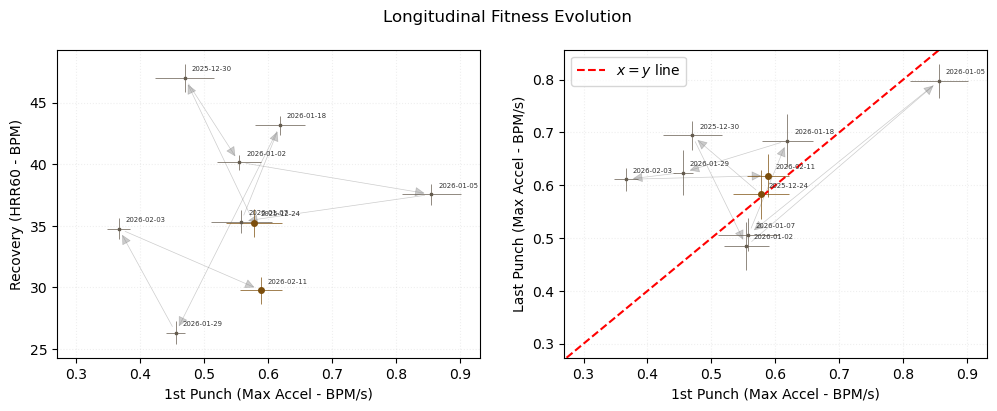

In [25]:
# report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0.3, 0.3), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


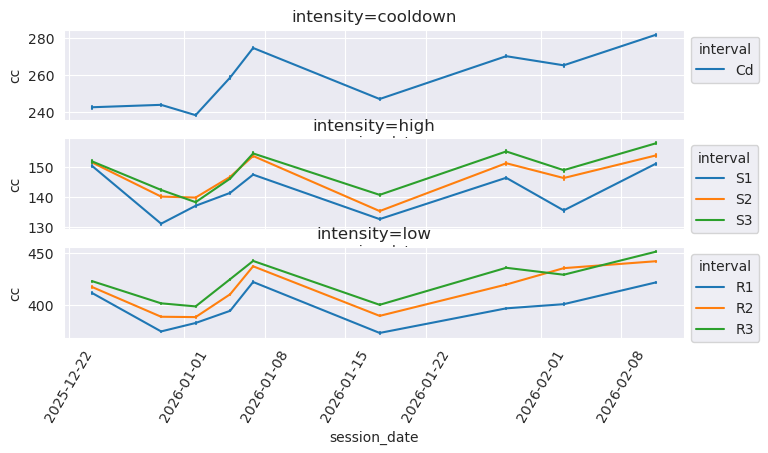

In [26]:
with sns.axes_style("darkgrid"):
    report.plot_cardiac_cost()